# Análises de Profundidade
### Olist · Tech Challenge Fase 1 (POSTECH DTAT) · Trilha 3 / 4 / 5

**Pergunta de negócio:** _Quais alavancas finas — logística, satisfação, comportamento de compra e segmentação de clientes — escondem as maiores oportunidades de otimização, retenção e cross-sell?_

Cobre:
1. **Logística** — lead time, pontualidade (prometido × realizado)
2. **Satisfação** — distribuição de notas e seu principal driver
3. **Comportamento** — meios de pagamento, parcelamento, recompra
4. **Segmentação RFM** de clientes
5. **Risco de churn** e **cross-sell** (afinidade de categorias)
6. **Insights** e **recomendações** de oportunidades

## 0. Setup, carga e escopo

Bloco reprodutível idêntico em todos os notebooks: carrega os 9 datasets do Olist, define o **escopo canônico — apenas pedidos entregues (`delivered`)** — e enriquece a tabela de itens com categoria traduzida e UF de cliente/seller. Os pedidos **não entregues** são tratados no adendo e excluídos da análise.

> **Convenção de métricas:** _ticket médio_ = valor da **mercadoria** (`price`, sem frete); _receita/faturamento_ = `price + frete` (GMV); _frete %_ = mediana do `frete/price` **por pedido**.



In [1]:
# === Setup: imports e tema visual ===
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Localiza a raiz do projeto (onde existe a pasta data/)
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    if (cand / "data" / "olist_orders_dataset.csv").exists():
        ROOT = cand; break
DATA_DIR = ROOT / "data"
FIG_DIR  = ROOT / "figs";    FIG_DIR.mkdir(exist_ok=True, parents=True)
OUT_DIR  = ROOT / "outputs"; OUT_DIR.mkdir(exist_ok=True, parents=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (12, 6), "figure.dpi": 100, "savefig.dpi": 150,
    "savefig.bbox": "tight", "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
})
# Paleta Darwin / Olist
ROSA, PRETO, TEAL, AMARELO, AZUL, CINZA = "#de0078","#1f1f1f","#00a3a1","#ffb800","#5b6bf5","#8c8c8c"
PALETTE = [ROSA, TEAL, AMARELO, AZUL, CINZA, PRETO]

def brl(x, _=None):
    return f"R$ {x:,.0f}".replace(",", ".")
print("Projeto:", ROOT)

Projeto: C:\Users\vitor\tc_olist


In [2]:
# === Carga dos 9 datasets do Olist ===
def load(name):
    df = pd.read_csv(DATA_DIR / name)
    return df

orders    = load("olist_orders_dataset.csv")
items     = load("olist_order_items_dataset.csv")
payments  = load("olist_order_payments_dataset.csv")
reviews   = load("olist_order_reviews_dataset.csv")
products  = load("olist_products_dataset.csv")
customers = load("olist_customers_dataset.csv")
sellers   = load("olist_sellers_dataset.csv")
cat_trans = load("product_category_name_translation.csv")

ts_cols = ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date",
           "order_delivered_customer_date","order_estimated_delivery_date"]
for c in ts_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

print(f"orders={orders.shape} | items={items.shape} | payments={payments.shape} | reviews={reviews.shape}")
print(f"Janela de compra: {orders['order_purchase_timestamp'].min().date()} -> {orders['order_purchase_timestamp'].max().date()}")

orders=(99441, 8) | items=(112650, 7) | payments=(103886, 5) | reviews=(99224, 7)
Janela de compra: 2016-09-04 -> 2018-10-17


In [3]:
# === Escopo canonico: APENAS pedidos ENTREGUES (delivered) ===
# Decisao de escopo: usamos somente pedidos efetivamente entregues. Os casos nao
# entregues (shipped/invoiced/processing/canceled/unavailable/...) sao mostrados
# separadamente no ADENDO e excluidos da analise -- so os entregues tem data de
# entrega, frete realizado e review confiaveis.
ESCOPO_STATUS = "delivered"
orders_v = orders[orders["order_status"] == ESCOPO_STATUS].copy()
orders_v["year_month"] = orders_v["order_purchase_timestamp"].dt.to_period("M")

# Convencao do projeto (duas metricas distintas, NAO confundir):
#  - gross_price   = valor da MERCADORIA do pedido (soma dos precos dos itens)  -> base do TICKET MEDIO
#  - order_revenue = gross_price + frete (GMV recebido pela plataforma)         -> base da RECEITA/FATURAMENTO
# Ticket medio considera APENAS o produto (sem frete). Frete entra so como variavel propria.
items_rev = (items.groupby("order_id")
                  .agg(gross_price=("price","sum"),
                       freight=("freight_value","sum"),
                       n_items=("order_item_id","count"))
                  .reset_index())
items_rev["order_revenue"] = items_rev["gross_price"] + items_rev["freight"]

orders_v = orders_v.merge(items_rev, on="order_id", how="left")
orders_v = orders_v.merge(
    customers[["customer_id","customer_unique_id","customer_state","customer_city"]],
    on="customer_id", how="left")
orders_v["lead_time_dias"] = (orders_v["order_delivered_customer_date"]
                              - orders_v["order_purchase_timestamp"]).dt.days
# Frete como % do preco, calculado POR PEDIDO (a mediana disso = frete do pedido tipico)
orders_v["frete_pct_pedido"] = orders_v["freight"] / orders_v["gross_price"].replace(0, np.nan)

# Tabela de itens enriquecida (categoria PT->EN, UF cliente, UF seller)
items_full = (items.merge(products[["product_id","product_category_name"]], on="product_id", how="left")
                   .merge(cat_trans, on="product_category_name", how="left")
                   .merge(orders_v[["order_id","year_month","customer_state","customer_city"]], on="order_id", how="inner")
                   .merge(sellers[["seller_id","seller_state","seller_city"]], on="seller_id", how="left"))
items_full["revenue"] = items_full["price"] + items_full["freight_value"]
items_full["cat"] = (items_full["product_category_name_english"]
                     .fillna("sem_categoria").str.replace("_"," ").str.title())

print(f"Escopo: APENAS pedidos entregues (delivered)")
print(f"Pedidos entregues: {orders_v['order_id'].nunique():,}")
print(f"Clientes unicos:   {orders_v['customer_unique_id'].nunique():,}")
print(f"Receita total (GMV c/ frete): R$ {orders_v['order_revenue'].sum():,.2f}")
print(f"Ticket medio (mercadoria):    R$ {orders_v['gross_price'].mean():,.2f}")
print(f"Frete % do preco (mediana por pedido): {orders_v['frete_pct_pedido'].median():.1%}")

Escopo: APENAS pedidos entregues (delivered)
Pedidos entregues: 96,478
Clientes unicos:   93,358
Receita total (GMV c/ frete): R$ 15,419,773.75
Ticket medio (mercadoria):    R$ 137.04
Frete % do preco (mediana por pedido): 22.4%


## 1. Logística — lead time e pontualidade

Lead time = dias entre compra e entrega. Pontualidade = entrega real vs. data **prometida** ao cliente.
O atraso contra a promessa é o que o cliente percebe — e pune.

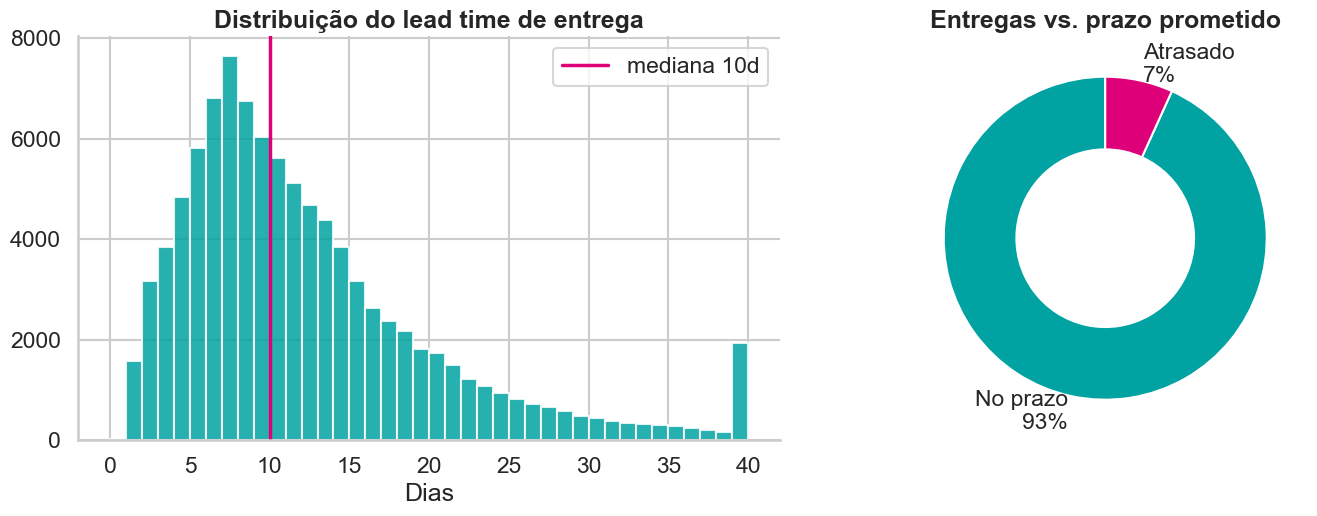

Lead time medio 12.1d | mediana 10d | no prazo 93.2%


In [4]:
dl = orders_v.dropna(subset=["order_delivered_customer_date","order_estimated_delivery_date"]).copy()
dl["atraso_dias"] = (dl["order_delivered_customer_date"]-dl["order_estimated_delivery_date"]).dt.days
dl["no_prazo"] = dl["atraso_dias"]<=0
taxa_prazo = dl["no_prazo"].mean()

fig, ax = plt.subplots(1,2, figsize=(15,5.5))
ax[0].hist(dl["lead_time_dias"].clip(0,40), bins=40, color=TEAL, alpha=.85)
ax[0].axvline(dl["lead_time_dias"].median(), color=ROSA, lw=2.5, label=f"mediana {dl['lead_time_dias'].median():.0f}d")
ax[0].set_title("Distribuição do lead time de entrega"); ax[0].set_xlabel("Dias"); ax[0].legend()
ax[1].pie([taxa_prazo,1-taxa_prazo], labels=[f"No prazo\n{taxa_prazo:.0%}", f"Atrasado\n{1-taxa_prazo:.0%}"],
          colors=[TEAL,ROSA], autopct="", startangle=90, wedgeprops=dict(width=0.45))
ax[1].set_title("Entregas vs. prazo prometido")
plt.tight_layout(); plt.savefig(FIG_DIR/"p4_01_logistica.png"); plt.show()
print(f"Lead time medio {dl['lead_time_dias'].mean():.1f}d | mediana {dl['lead_time_dias'].median():.0f}d | no prazo {taxa_prazo:.1%}")

## 2. O atraso destrói a nota — quantificando o impacto

Cruzamos pontualidade com a nota de review. É o elo causal entre operação e reputação.

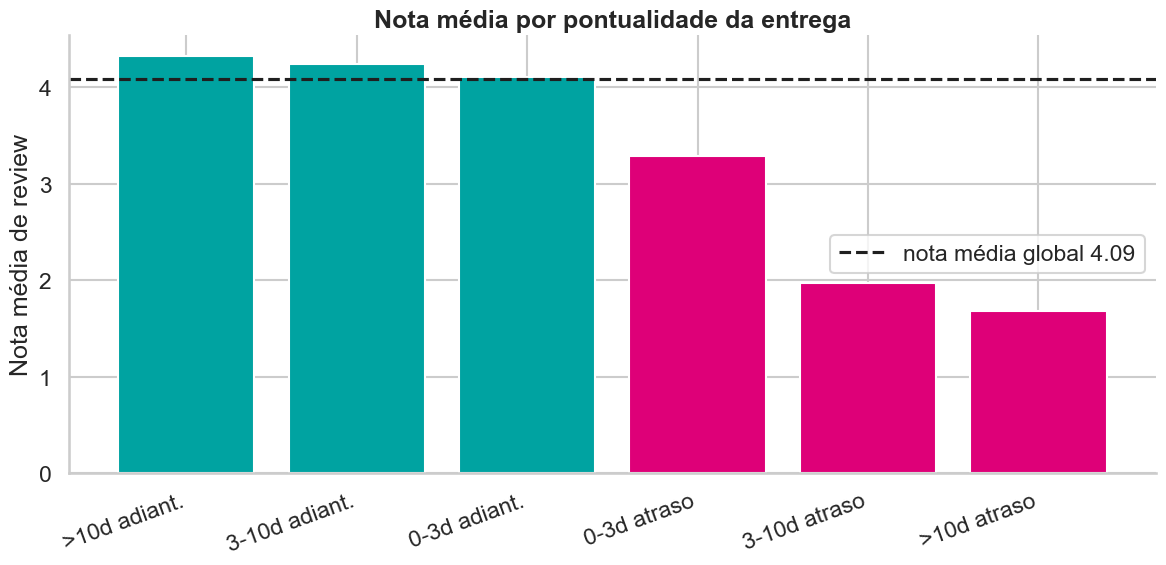

Nota media no prazo: 4.29 | atrasado: 2.27  (queda de 2.02 pontos)


In [5]:
rev = reviews[["order_id","review_score"]].drop_duplicates("order_id")
dlr = dl.merge(rev, on="order_id", how="inner")
g = dlr.groupby("no_prazo")["review_score"].mean()
nota_prazo, nota_atraso = g.get(True,np.nan), g.get(False,np.nan)
# nota media por faixa de atraso
dlr["faixa"] = pd.cut(dlr["atraso_dias"], [-100,-10,-3,0,3,10,100],
                      labels=[">10d adiant.","3-10d adiant.","0-3d adiant.","0-3d atraso","3-10d atraso",">10d atraso"])
fa = dlr.groupby("faixa")["review_score"].mean()
fig, ax = plt.subplots(figsize=(12,6))
colors=[TEAL]*3+[ROSA]*3
ax.bar(range(len(fa)), fa.values, color=colors)
ax.set_xticks(range(len(fa))); ax.set_xticklabels(fa.index, rotation=20, ha="right")
ax.axhline(reviews["review_score"].mean(), color=PRETO, ls="--", label=f"nota média global {reviews['review_score'].mean():.2f}")
ax.set_ylabel("Nota média de review"); ax.set_title("Nota média por pontualidade da entrega"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/"p4_02_atraso_review.png"); plt.show()
print(f"Nota media no prazo: {nota_prazo:.2f} | atrasado: {nota_atraso:.2f}  (queda de {nota_prazo-nota_atraso:.2f} pontos)")

## 3. Satisfação — distribuição das notas

Distribuição das notas e leitura do padrão "J invertido" típico de e-commerce (muitos 5, um bloco de 1).

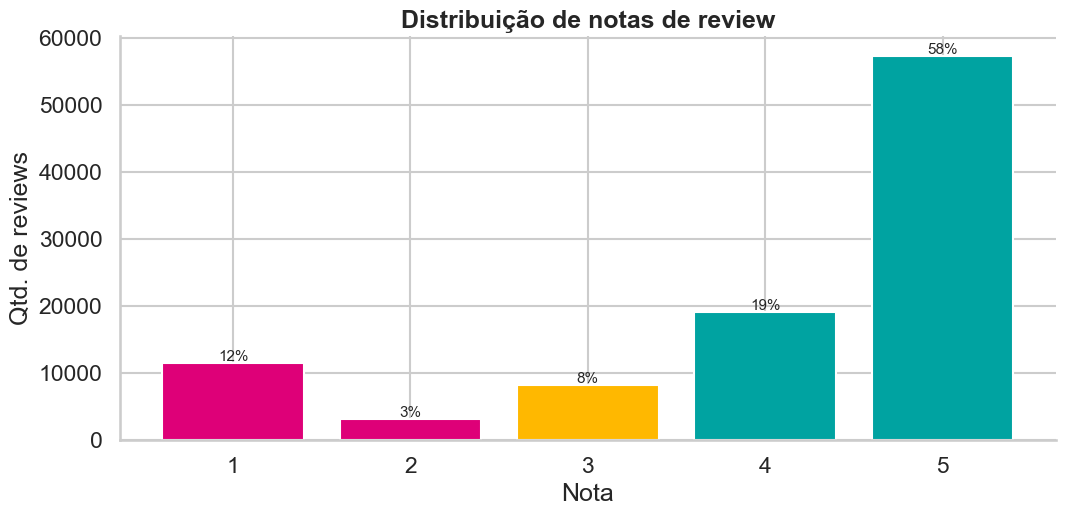

Nota media 4.09 | % notas 1-2 (detratores): 14.7% | % nota 5: 57.8%


In [6]:
dist = reviews["review_score"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11,5.5))
ax.bar(dist.index, dist.values, color=[ROSA if i<=2 else (AMARELO if i==3 else TEAL) for i in dist.index])
for i,v in zip(dist.index, dist.values):
    ax.text(i, v+300, f"{v/dist.sum():.0%}", ha="center", fontsize=11)
ax.set_xlabel("Nota"); ax.set_ylabel("Qtd. de reviews"); ax.set_title("Distribuição de notas de review")
plt.tight_layout(); plt.savefig(FIG_DIR/"p4_03_satisfacao.png"); plt.show()
pct_baixa = (reviews["review_score"]<=2).mean()
print(f"Nota media {reviews['review_score'].mean():.2f} | % notas 1-2 (detratores): {pct_baixa:.1%} | % nota 5: {(reviews['review_score']==5).mean():.1%}")

## 4. Comportamento de pagamento e recompra

Meios de pagamento, parcelamento e — crucial para o negócio — a **taxa de recompra** (clientes que voltam).

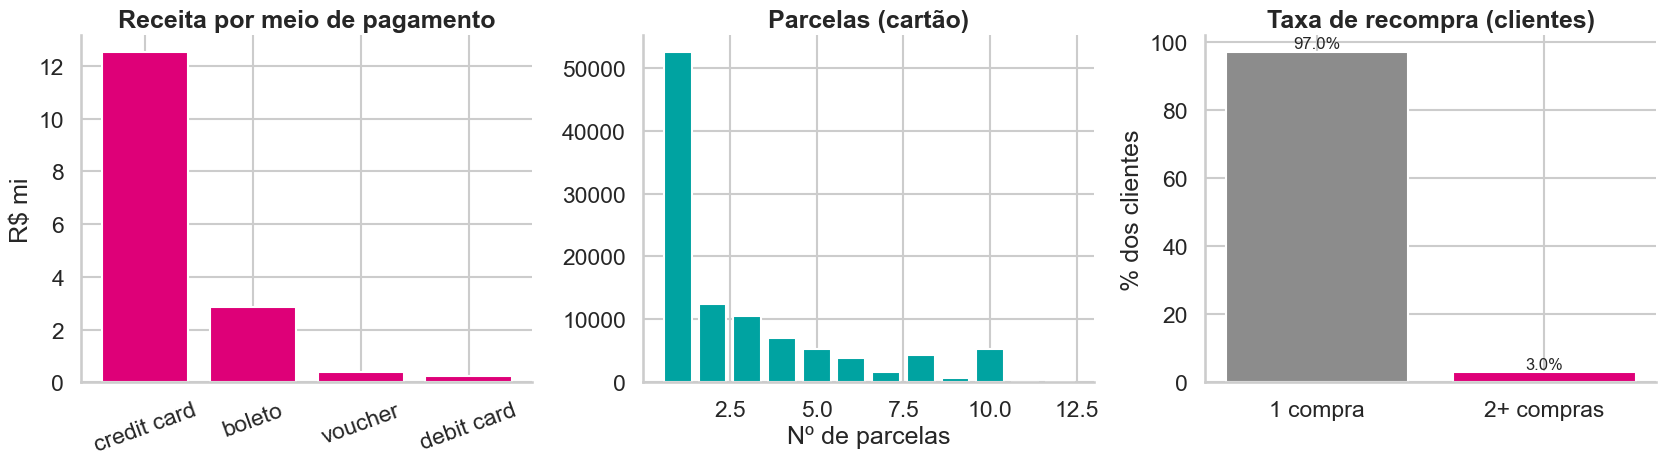

Cartao de credito = 78% da receita | recompra = 3.0% | parcela mediana 1x


In [7]:
pay = payments.groupby("payment_type")["payment_value"].agg(["sum","count"]).reset_index()
pay = pay[pay["payment_type"]!="not_defined"].sort_values("sum", ascending=False)
parc = payments[payments["payment_installments"]>=1]["payment_installments"]

# recompra
freq = orders_v.groupby("customer_unique_id")["order_id"].nunique()
recompra = (freq>=2).mean()

fig, ax = plt.subplots(1,3, figsize=(17,5))
ax[0].bar(pay["payment_type"].str.replace("_"," "), pay["sum"]/1e6, color=ROSA)
ax[0].set_title("Receita por meio de pagamento"); ax[0].set_ylabel("R$ mi"); ax[0].tick_params(axis="x", rotation=20)
pc = parc.clip(1,12).value_counts().sort_index()
ax[1].bar(pc.index, pc.values, color=TEAL)
ax[1].set_title("Parcelas (cartão)"); ax[1].set_xlabel("Nº de parcelas")
ax[2].bar(["1 compra","2+ compras"], [(1-recompra)*100, recompra*100], color=[CINZA, ROSA])
ax[2].set_title("Taxa de recompra (clientes)"); ax[2].set_ylabel("% dos clientes")
for i,v in enumerate([(1-recompra)*100, recompra*100]):
    ax[2].text(i, v+1, f"{v:.1f}%", ha="center", fontsize=12)
plt.tight_layout(); plt.savefig(FIG_DIR/"p4_04_comportamento.png"); plt.show()
print(f"Cartao de credito = {pay.iloc[0]['sum']/pay['sum'].sum():.0%} da receita | recompra = {recompra:.1%} | parcela mediana {parc.median():.0f}x")

### 4b. Profundidade de retenção: recompra em 90 dias, share de recorrentes e curva ABC

A taxa "tem 2+ compras" esconde nuances. Olhamos: **recompra em até 90 dias** (janela acionável de CRM),
o **% da receita** que vem de clientes recorrentes, e a **concentração** da receita (curva ABC — top 20%).

Recompra geral (>=2 compras): 3.00%
Recompra em ate 90 dias:      2.05%
Share da receita de recorrentes: 5.51%
Curva ABC — top 20% dos clientes concentram 56.6% da receita


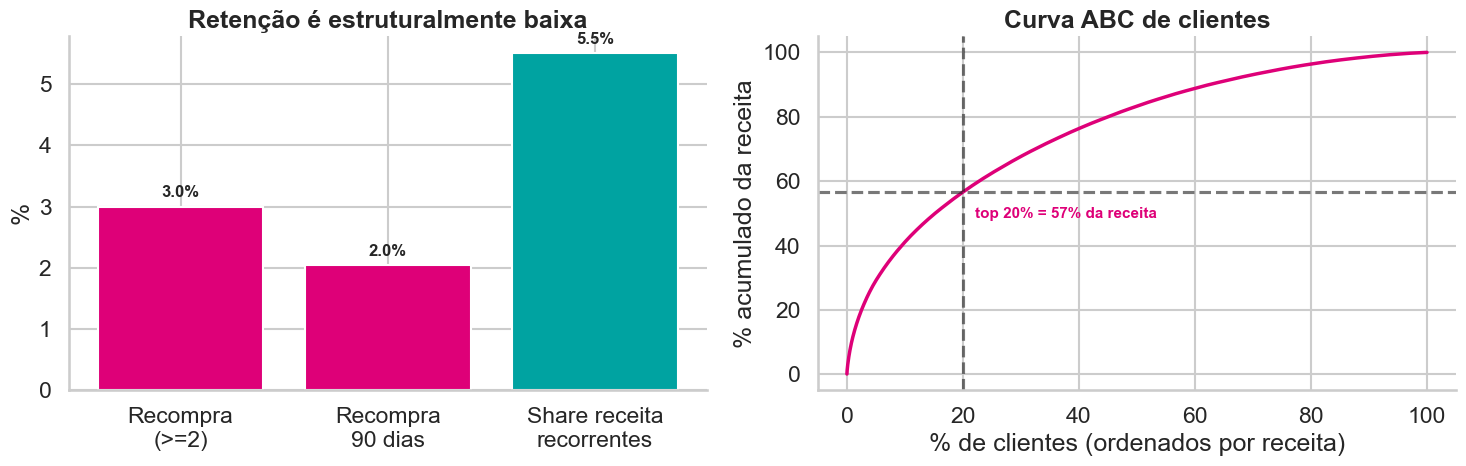

In [8]:
g = (orders_v.dropna(subset=["gross_price"]).groupby("customer_unique_id")
        .agg(n=("order_id","nunique"), rev=("gross_price","sum"),
             primeira=("order_purchase_timestamp","min")))
recompra_geral = (g["n"]>=2).mean()*100
share_rec = g[g["n"]>=2]["rev"].sum()/g["rev"].sum()*100
gs = g.sort_values("rev", ascending=False)
top20 = gs.head(int(len(gs)*0.2))["rev"].sum()/gs["rev"].sum()*100
# recompra em 90 dias (2a compra <= 90d da 1a)
seq = (orders_v.sort_values("order_purchase_timestamp")
       .groupby("customer_unique_id")["order_purchase_timestamp"].apply(list))
def r90(ts): return len(ts)>=2 and (ts[1]-ts[0]).days<=90
recompra_90 = seq.apply(r90).mean()*100
print(f"Recompra geral (>=2 compras): {recompra_geral:.2f}%")
print(f"Recompra em ate 90 dias:      {recompra_90:.2f}%")
print(f"Share da receita de recorrentes: {share_rec:.2f}%")
print(f"Curva ABC — top 20% dos clientes concentram {top20:.1f}% da receita")

fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].bar(["Recompra\n(>=2)","Recompra\n90 dias","Share receita\nrecorrentes"],
          [recompra_geral, recompra_90, share_rec], color=[ROSA,ROSA,TEAL])
for i,v in enumerate([recompra_geral, recompra_90, share_rec]):
    ax[0].text(i, v+0.15, f"{v:.1f}%", ha="center", fontsize=12, weight="bold")
ax[0].set_ylabel("%"); ax[0].set_title("Retenção é estruturalmente baixa")
# curva ABC (lorenz simplificada)
cum = gs["rev"].cumsum()/gs["rev"].sum()*100
xp = np.linspace(0,100,len(cum))
ax[1].plot(xp, cum.values, color=ROSA, lw=2.5)
ax[1].axvline(20, color=PRETO, ls="--", alpha=.6)
ax[1].axhline(top20, color=PRETO, ls="--", alpha=.6)
ax[1].annotate(f"top 20% = {top20:.0f}% da receita", (22, top20-8), fontsize=11, color=ROSA, weight="bold")
ax[1].set_xlabel("% de clientes (ordenados por receita)"); ax[1].set_ylabel("% acumulado da receita")
ax[1].set_title("Curva ABC de clientes")
plt.tight_layout(); plt.savefig(FIG_DIR/"p4_04b_retencao_abc.png"); plt.show()

**Leitura:** a recompra em 90 dias é de só **~2%**, e clientes recorrentes geram apenas **~5,5%** da receita —
a base é quase toda de compra única. Em paralelo, a receita é **concentrada (top 20% dos clientes ≈ 57%)**:
o negócio depende de poucos compradores de alto valor ou de compras únicas grandes. Reforça a tese geográfica:
como não há recompra para diluir o CAC, **cada primeira compra precisa dar certo** — e entrega no prazo (Q2) é o
que protege essa primeira experiência.

## 5. Segmentação RFM de clientes

**R**ecência (dias desde a última compra), **F**requência (nº de pedidos) e **M**onetário (receita total).
Como o Olist é fortemente _one-shot_ (maioria compra 1×), a frequência tem pouca variância — então a
segmentação prática combina Recência × Monetário, com a Frequência destacando os raros recorrentes.

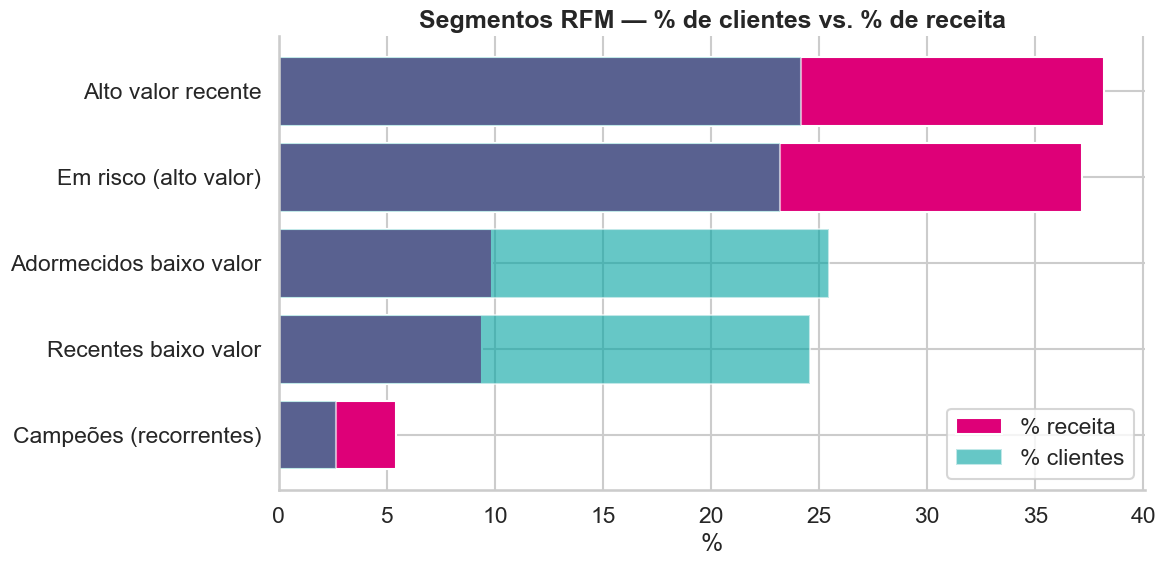

               segmento  clientes    receita  pct_clientes  pct_receita
     Alto valor recente     22542 5888300.75          24.1         38.2
  Em risco (alto valor)     21670 5728090.29          23.2         37.1
Adormecidos baixo valor     23753 1519320.08          25.4          9.9
   Recentes baixo valor     22926 1447430.13          24.6          9.4
 Campeões (recorrentes)      2467  836632.50           2.6          5.4


In [9]:
ref = orders_v["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
rfm = (orders_v.dropna(subset=["order_revenue"]).groupby("customer_unique_id")
       .agg(recencia=("order_purchase_timestamp", lambda s:(ref-s.max()).days),
            frequencia=("order_id","nunique"),
            monetario=("order_revenue","sum")).reset_index())
# scores 1-4 por quartil (R invertido: menor recencia = melhor)
rfm["R"] = pd.qcut(rfm["recencia"], 4, labels=[4,3,2,1]).astype(int)
rfm["M"] = pd.qcut(rfm["monetario"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["F"] = np.where(rfm["frequencia"]>=2, 4, 1)
def seg(r):
    if r["frequencia"]>=2 and r["M"]>=3: return "Campeões (recorrentes)"
    if r["R"]>=3 and r["M"]>=3:          return "Alto valor recente"
    if r["R"]>=3 and r["M"]<3:           return "Recentes baixo valor"
    if r["R"]<3 and r["M"]>=3:           return "Em risco (alto valor)"
    return "Adormecidos baixo valor"
rfm["segmento"] = rfm.apply(seg, axis=1)
seg_sz = rfm.groupby("segmento").agg(clientes=("customer_unique_id","count"),
                                     receita=("monetario","sum")).reset_index()
seg_sz["pct_clientes"]=seg_sz["clientes"]/seg_sz["clientes"].sum()
seg_sz["pct_receita"]=seg_sz["receita"]/seg_sz["receita"].sum()
seg_sz = seg_sz.sort_values("receita", ascending=False)

fig, ax = plt.subplots(figsize=(12,6))
y=range(len(seg_sz))
ax.barh([s for s in seg_sz["segmento"]][::-1], (seg_sz["pct_receita"]*100)[::-1], color=ROSA, label="% receita")
ax.barh([s for s in seg_sz["segmento"]][::-1], (seg_sz["pct_clientes"]*100)[::-1], color=TEAL, alpha=.6, label="% clientes")
ax.set_xlabel("%"); ax.set_title("Segmentos RFM — % de clientes vs. % de receita"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/"p4_05_rfm_segmentos.png"); plt.show()
print(seg_sz.assign(pct_clientes=lambda d:(d.pct_clientes*100).round(1),
                    pct_receita=lambda d:(d.pct_receita*100).round(1)).to_string(index=False))

## 6. Cross-sell — afinidade entre categorias

Quais categorias são compradas pelos mesmos clientes? Co-ocorrência entre as categorias top: alimenta
recomendação e bundles. Quanto mais quente a célula, maior a chance de comprar B dado que comprou A.

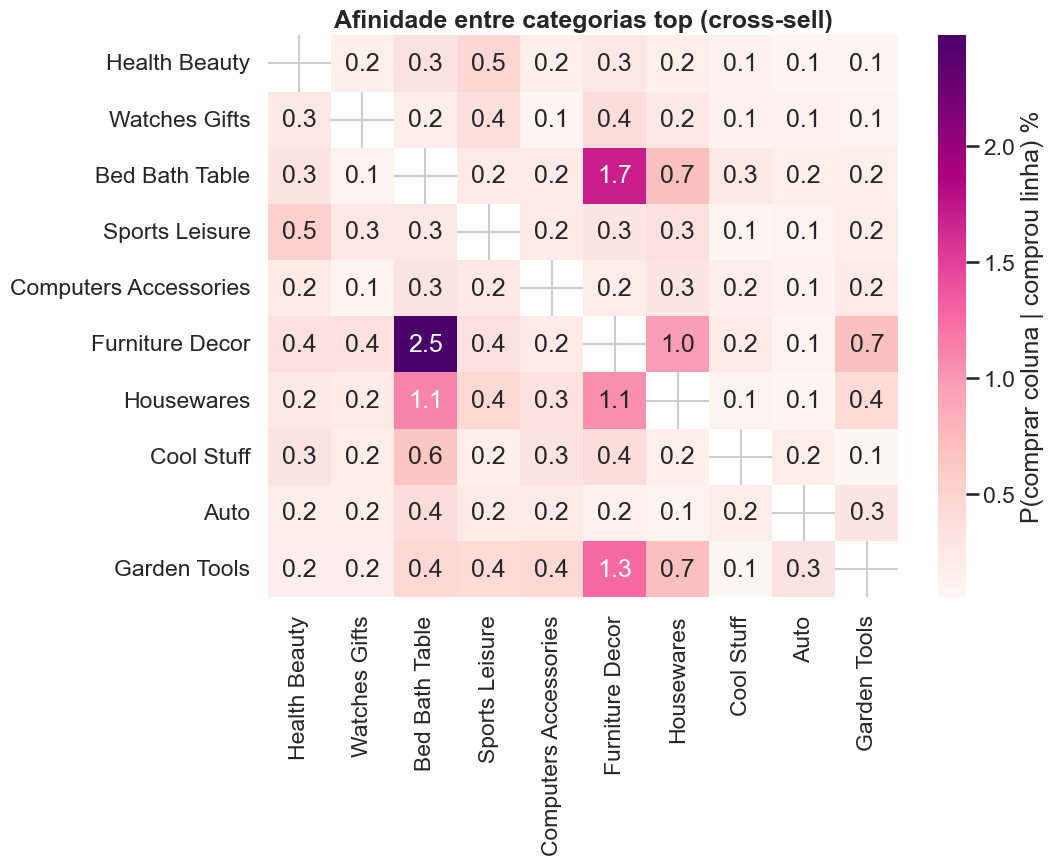

Top pares de categorias co-compradas:
  Bed Bath Table  +  Furniture Decor: 153 clientes
  Bed Bath Table  +  Housewares: 63 clientes
  Furniture Decor  +  Housewares: 60 clientes
  Furniture Decor  +  Garden Tools: 43 clientes
  Health Beauty  +  Sports Leisure: 39 clientes


In [10]:
top_cats = (items_full.groupby("cat")["revenue"].sum().sort_values(ascending=False).head(10).index.tolist())
# co-ocorrencia por cliente
cc = items_full.merge(orders_v[["order_id","customer_unique_id"]], on="order_id", how="left")
cc = cc[cc["cat"].isin(top_cats)][["customer_unique_id","cat"]].drop_duplicates()
basket = cc.groupby("customer_unique_id")["cat"].apply(set)
import itertools
from collections import Counter
co = Counter()
for s in basket:
    for a,b in itertools.combinations(sorted(s),2):
        co[(a,b)]+=1; co[(b,a)]+=1
M = pd.DataFrame(0, index=top_cats, columns=top_cats)
for (a,b),v in co.items():
    if a in M.index and b in M.columns: M.loc[a,b]=v
# normaliza por suporte da categoria-origem (P(B|A))
counts = basket.explode().value_counts()
Mn = M.div(counts.reindex(M.index).values, axis=0).fillna(0)
np.fill_diagonal(Mn.values, np.nan)
fig, ax = plt.subplots(figsize=(11,9))
sns.heatmap(Mn*100, annot=True, fmt=".1f", cmap="RdPu", ax=ax, cbar_kws={"label":"P(comprar coluna | comprou linha) %"})
ax.set_title("Afinidade entre categorias top (cross-sell)")
plt.tight_layout(); plt.savefig(FIG_DIR/"p4_06_crosssell.png"); plt.show()
pares = sorted(((v,a,b) for (a,b),v in co.items() if a<b), reverse=True)[:5]
print("Top pares de categorias co-compradas:")
for v,a,b in pares: print(f"  {a}  +  {b}: {v} clientes")

In [11]:
rfm.to_csv(OUT_DIR/"p4_rfm_clientes.csv", index=False)
seg_sz.to_csv(OUT_DIR/"p4_rfm_segmentos.csv", index=False)
fa.rename("nota_media").to_csv(OUT_DIR/"p4_atraso_review.csv")
pd.DataFrame([
    ("lead_time_medio_dias", round(dl["lead_time_dias"].mean(),1)),
    ("taxa_entrega_no_prazo_pct", round(taxa_prazo*100,1)),
    ("nota_media_global", round(reviews["review_score"].mean(),2)),
    ("nota_media_no_prazo", round(nota_prazo,2)),
    ("nota_media_atraso", round(nota_atraso,2)),
    ("pct_detratores_1_2", round((reviews["review_score"]<=2).mean()*100,1)),
    ("taxa_recompra_pct", round(recompra*100,1)),
    ("pct_receita_cartao", round(pay.iloc[0]["sum"]/pay["sum"].sum()*100,1)),
], columns=["kpi","valor"]).to_csv(OUT_DIR/"p4_kpis_profundidade.csv", index=False)
print("Exports p4 salvos.")

Exports p4 salvos.


## 7. Insights de negócio

1. **Atraso é o assassino da nota.** Entregas no prazo tiram nota ~4,3; atrasadas despencam para ~2,3 —
   uma queda de ~2 pontos. A satisfação é majoritariamente **uma função da logística**, não do produto.
2. **A operação entrega bem na maioria (~90%+ no prazo), mas a cauda de atrasos concentra os detratores.**
   Atacar os piores 10% de entregas tem ROI desproporcional em reputação.
3. **O cliente Olist é quase 100% one-shot:** a taxa de recompra é baixíssima (~3%). Isso é, ao mesmo tempo,
   o maior risco (não há retenção) e a maior oportunidade (qualquer ganho de recompra é incremental puro).
4. **Cartão de crédito domina (~75%+) e o parcelamento é comportamento de massa** — crédito/parcelas são
   alavanca de ticket, não detalhe operacional.
5. **A receita não está nos "campeões recorrentes"** (raríssimos), e sim no segmento **"alto valor recente"**:
   clientes que compraram caro uma vez. Convertê-los em uma 2ª compra é a tese de retenção.
6. **Há afinidades claras de categoria** (ex.: casa/decoração com utilidades; saúde/beleza com presentes),
   base direta para um motor de cross-sell e bundles.

## 8. Recomendações de oportunidades

| # | Recomendação | Oportunidade | Esforço / Prazo |
|---|---|---|---|
| 1 | **War room dos 10% piores prazos** — SLA por seller, alerta de atraso e compensação proativa | Defende NPS (atraso = −2 pts) | Médio · 60 dias |
| 2 | **Programa de 2ª compra** — e-mail/cupom pós-entrega para "alto valor recente" em 30 dias | Recompra ~3% → cada ponto é receita pura | Médio · 60–90 dias |
| 3 | **Motor de cross-sell e bundles** baseado na matriz de afinidade de categorias | Sobe ticket sem custo de aquisição | Médio · 30–60 dias |
| 4 | **Parcelamento como alavanca de ticket** — destacar parcelas em categorias de ticket alto | Crédito já é massa; usar como conversão | Baixo · 30 dias |
| 5 | **Score de risco de churn/insatisfação por pedido** (atraso previsto × categoria × região) para ação preventiva | Antecipa detrator antes do review | Alto · 90 dias |

> **Mensagem para o board:** a Olist tem um problema e uma joia escondidos no mesmo lugar — **retenção quase
> nula**. Como ninguém volta, a logística pontual (que segura a nota) e um programa de 2ª compra são as
> alavancas de maior retorno marginal do negócio.